# 02 Sinusoids, Complex Exponentials, and Phase

## Purpose

This notebook builds the next layer of DSP intuition after sampling: how sinusoid amplitude, frequency, and phase shape a waveform, why complex exponentials are a compact way to represent oscillation, and how phase shift connects directly to time delay and later array-processing ideas.

## Prerequisites

- Notebook 01: Signals, systems, and sampling
- Basic algebra and trigonometry

## Learning Objectives

By the end of this notebook, you should be able to:

- describe the role of amplitude, frequency, and phase in a sinusoid,
- explain what a phase shift means geometrically and in time,
- interpret a complex exponential through its real part, imaginary part, and rotating phasor view,
- explain why negative frequency appears naturally in the complex representation,
- and connect phase differences to delay, coherence, and later beamforming and SAS intuition.


## New Terms In This Notebook

- **Complex exponential**: a signal of the form $A e^{j(2\pi f t + \phi)}$, which packages oscillation into one complex-valued expression.
- **Phasor**: the rotating arrow in the complex plane used to visualize the magnitude and phase of a complex exponential at an instant in time.
- **Quadrature components**: the real and imaginary parts of a complex exponential. They are separated by $90^\circ$ of phase.
- **Imaginary part**: not usually a second physical waveform measured by a second sensor. It is the orthogonal bookkeeping coordinate that, together with the real part, fully specifies the phasor.
- **Positive frequency / negative frequency**: the two opposite rotation directions in the complex plane. Positive frequency rotates counterclockwise, while negative frequency rotates clockwise.
- **Wrapped phase**: phase reported modulo $2\pi$, so angles that differ by whole turns are treated as equivalent.
- **Coherence**: the condition that signals maintain a stable phase relationship, which allows them to add constructively.

## Big Picture

A sampled signal is often built from oscillatory components. To reason about filtering, spectra, beam steering, or coherent imaging later, we need to be fluent with the simplest oscillation model first: the sinusoid.

Complex exponentials are not a separate physical waveform hiding behind the math. They are a bookkeeping tool that makes phase and frequency relationships easier to manipulate, especially when we care about relative delay and coherent summation.

That bookkeeping matters because real sinusoids become awkward once we start asking engineering questions. With only real sinusoids, phase shifts, delays, and sums of many components are still possible to write down, but the algebra becomes clumsy. Complex exponentials let us represent amplitude and phase together, turn phase shifts into multiplication by a complex number, and make the Fourier transform possible as a clean projection onto rotating basis functions.


In [1]:
import matplotlib.pyplot as plt
import numpy as np

from _bootstrap import bootstrap_src_path

bootstrap_src_path()

from sonar_py_lib.dsp import complex_exponential, sine_wave, time_axis
from sonar_py_lib.notebook_utils import set_plot_style
from sonar_py_lib.plotting import make_figure, plot_signal, plot_signals

set_plot_style()


## Assumptions

- We stay with ideal noise-free tones so phase relationships are easy to see.
- We use radians as the default phase unit in code, while sometimes reporting degrees for interpretation.
- We treat sinusoids as infinite-duration mathematical objects even though we only plot short windows.
- We focus on phase relative to a reference, because absolute phase alone is rarely meaningful in a measurement system.


## A Sinusoid Has Three Main Knobs

A real sinusoid can be written as

$$x(t) = A\sin(2\pi f t + \phi)$$

where:

- $A$ is amplitude,
- $f$ is frequency in hertz,
- and $\phi$ is phase in radians.

Amplitude changes vertical scale. Frequency changes how quickly the waveform oscillates. Phase shifts the waveform left or right relative to a reference.


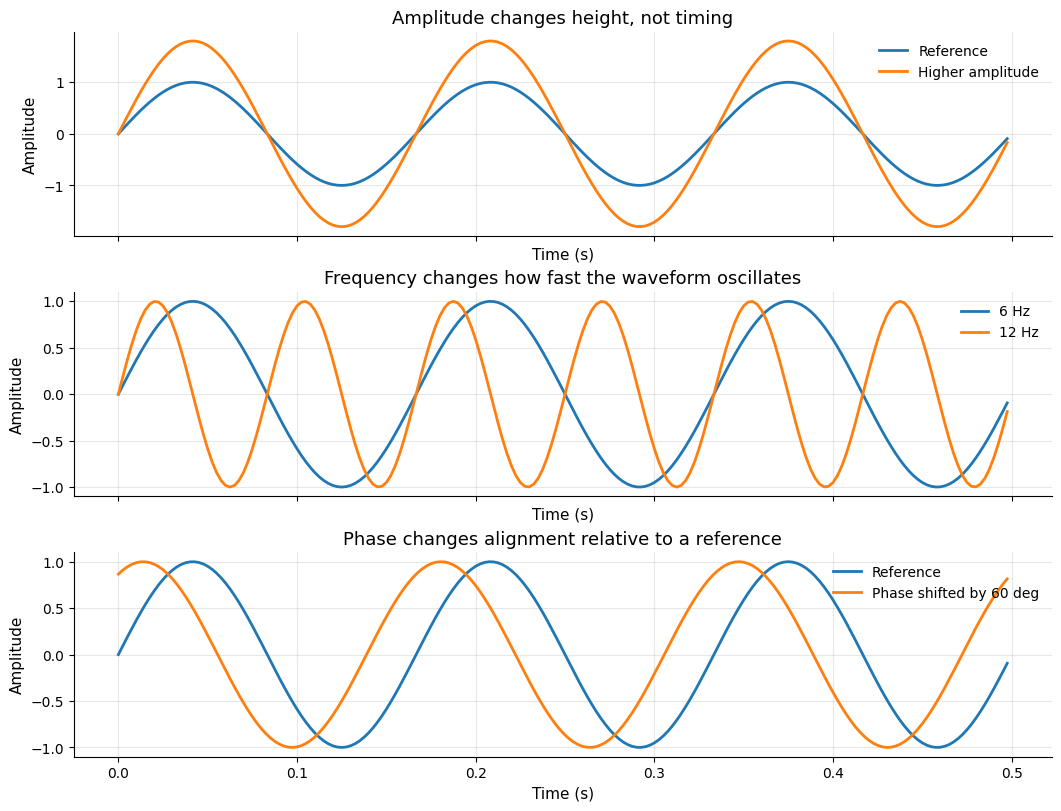

In [2]:
fs = 400.0
duration_s = 0.5
t, tone_ref = sine_wave(6.0, fs, duration_s, amplitude=1.0, phase_rad=0.0)
_, tone_high_amp = sine_wave(6.0, fs, duration_s, amplitude=1.8, phase_rad=0.0)
_, tone_high_freq = sine_wave(12.0, fs, duration_s, amplitude=1.0, phase_rad=0.0)
_, tone_phase = sine_wave(6.0, fs, duration_s, amplitude=1.0, phase_rad=np.pi / 3.0)

fig, axes = make_figure(nrows=3, ncols=1, figsize=(10.5, 8.0), sharex=True)
plot_signals(t, [tone_ref, tone_high_amp], ax=axes[0], labels=["Reference", "Higher amplitude"], title="Amplitude changes height, not timing", xlabel="Time (s)", ylabel="Amplitude")
plot_signals(t, [tone_ref, tone_high_freq], ax=axes[1], labels=["6 Hz", "12 Hz"], title="Frequency changes how fast the waveform oscillates", xlabel="Time (s)", ylabel="Amplitude")
plot_signals(t, [tone_ref, tone_phase], ax=axes[2], labels=["Reference", "Phase shifted by 60 deg"], title="Phase changes alignment relative to a reference", xlabel="Time (s)", ylabel="Amplitude")
for ax in axes:
    ax.legend(loc="upper right")
plt.show()


The third panel is the important one for later notebooks. The waveform did not get larger or faster. It simply moved relative to the reference. That relative shift is the basic language of interference, steering, and coherence.


## Phase Is a Relative Angle

One cycle corresponds to $2\pi$ radians or $360^\circ$. A phase difference tells us what fraction of a cycle one waveform is ahead of or behind another.

For a sinusoid at frequency $f$, a phase shift $\Delta \phi$ corresponds to a time shift

$$\Delta t = \frac{\Delta \phi}{2\pi f}. $$

This is why phase is frequency dependent. The same angular offset means a different physical delay at 200 Hz than it does at 2 kHz.


In [3]:
phase_deg = np.array([30.0, 60.0, 120.0])
phase_rad = np.deg2rad(phase_deg)
freqs_hz = np.array([5.0, 20.0])
delay_ms = 1e3 * phase_rad[:, None] / (2.0 * np.pi * freqs_hz[None, :])

print("Equivalent time delay for the same phase offset:")
for idx, deg in enumerate(phase_deg):
    print(f"  {deg:>5.0f} deg at {freqs_hz[0]:>4.0f} Hz -> {delay_ms[idx, 0]:6.2f} ms")
    print(f"  {deg:>5.0f} deg at {freqs_hz[1]:>4.0f} Hz -> {delay_ms[idx, 1]:6.2f} ms")


Equivalent time delay for the same phase offset:
     30 deg at    5 Hz ->  16.67 ms
     30 deg at   20 Hz ->   4.17 ms
     60 deg at    5 Hz ->  33.33 ms
     60 deg at   20 Hz ->   8.33 ms
    120 deg at    5 Hz ->  66.67 ms
    120 deg at   20 Hz ->  16.67 ms


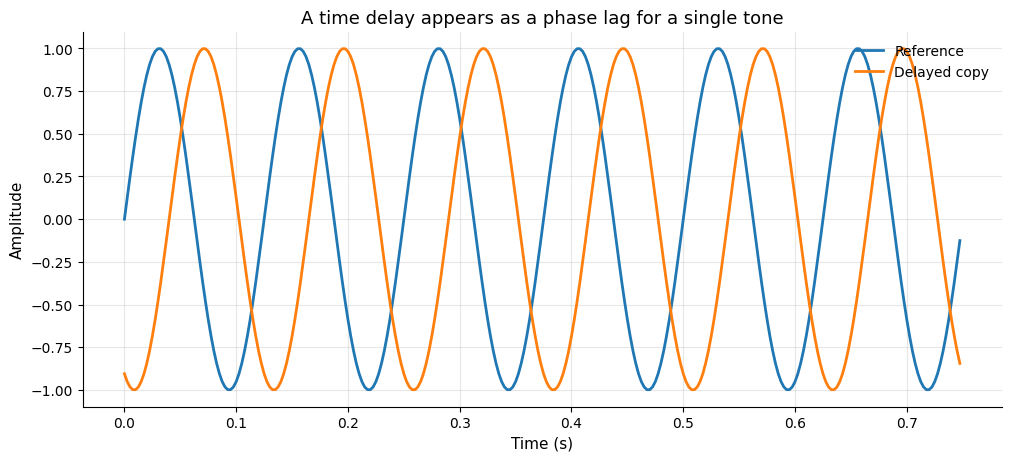

At 8.0 Hz, a delay of 40.0 ms corresponds to a wrapped phase lag of -115.2 deg.


In [4]:
freq_for_delay = 8.0
delay_s = 0.04
phase_delay_rad = 2.0 * np.pi * freq_for_delay * delay_s
phase_lag_wrapped = (-phase_delay_rad + np.pi) % (2.0 * np.pi) - np.pi

t_delay, x_ref = sine_wave(freq_for_delay, fs, 0.75, amplitude=1.0, phase_rad=0.0)
_, x_delayed = sine_wave(freq_for_delay, fs, 0.75, amplitude=1.0, phase_rad=-phase_delay_rad)

fig, ax = make_figure(figsize=(10.0, 4.5))
plot_signals(t_delay, [x_ref, x_delayed], ax=ax, labels=["Reference", "Delayed copy"], title="A time delay appears as a phase lag for a single tone", xlabel="Time (s)", ylabel="Amplitude")
ax.legend(loc="upper right")
plt.show()

print(f"At {freq_for_delay:.1f} Hz, a delay of {1e3 * delay_s:.1f} ms corresponds to a wrapped phase lag of {np.rad2deg(phase_lag_wrapped):.1f} deg.")


For a single tone, delay and phase shift are tightly linked. Later we will need a more careful statement for broadband signals, because different frequencies accumulate different phase shifts from the same delay.


## Complex Exponentials as a Tool for Representing and Manipulating Phase and Amplitude

If we only cared about plotting one real waveform, real sines and cosines
would be enough. The reason to introduce complex exponentials is that they
give us a cleaner way to represent one oscillatory component in terms of
amplitude and phase.

A complex exponential can be visualized as a rotating vector in the
complex plane, called a phasor. In that picture, the vector length
represents amplitude, and the vector angle relative to a reference
represents phase.

Using this representation makes several later operations much simpler:

- delay becomes a phase factor,
- summing coherent components becomes vector addition,
- and Fourier analysis becomes a comparison against rotating complex basis
functions.

Euler's identity gives

$$e^{j\theta} = \cos(\theta) + j\sin(\theta).$$

That means a complex exponential

$$A e^{j(2\pi f t + \phi)}$$

contains a cosine in its real part and a sine in its imaginary part. The imaginary part does not mean there is a hidden physical signal living somewhere else. It is the second coordinate of the rotating phasor, just as a point in the plane needs both an $x$ and a $y$ coordinate.

That is the real payoff: instead of tracking two coupled oscillations separately, we can treat them as one rotating complex quantity whose angle carries phase and whose length carries amplitude.


In [1]:
f_complex = 5.0
duration_complex = 0.8
phase0 = np.pi / 6.0
t_complex, z = complex_exponential(f_complex, fs, duration_complex, amplitude=1.0, phase_rad=phase0)

samples_per_cycle = int(fs / f_complex)
cycle_idx = np.arange(samples_per_cycle + 1)
phasor_marks = np.array([0, 5, 10, 15, 20])
mark_colors = [f"C{i}" for i in range(len(phasor_marks))]

fig, axes = make_figure(nrows=2, ncols=1, figsize=(10.5, 7.8))
plot_signals(t_complex[cycle_idx], [np.real(z[cycle_idx]), np.imag(z[cycle_idx])], ax=axes[0], labels=["Real part", "Imaginary part"], title="A complex exponential contains two quadrature oscillations", xlabel="Time (s)", ylabel="Amplitude")
for step, (idx, color) in enumerate(zip(phasor_marks, mark_colors)):
    axes[0].axvline(t_complex[idx], color=color, alpha=0.15, linewidth=1.0)
    axes[0].scatter([t_complex[idx]], [np.real(z[idx])], color=color, s=35, zorder=3)
    axes[0].scatter([t_complex[idx]], [np.imag(z[idx])], color=color, s=35, marker="s", zorder=3)
    axes[0].text(t_complex[idx], 1.12, f"t{step}", color=color, ha="center", va="bottom", fontsize=9)
axes[0].set_ylim(-1.1, 1.22)
axes[0].legend(loc="upper right")

theta = np.linspace(0.0, 2.0 * np.pi, 400)
axes[1].plot(np.cos(theta), np.sin(theta), color="0.85", linewidth=1.5)
axes[1].plot(np.real(z[cycle_idx]), np.imag(z[cycle_idx]), color="0.7", linewidth=1.5)
for step, (idx, color) in enumerate(zip(phasor_marks, mark_colors)):
    axes[1].annotate("", xy=(np.real(z[idx]), np.imag(z[idx])), xytext=(0.0, 0.0), arrowprops=dict(arrowstyle="->", color=color, lw=2.0))
    axes[1].scatter([np.real(z[idx])], [np.imag(z[idx])], color=color, s=35, zorder=3)
    axes[1].text(np.real(z[idx]) + 0.05, np.imag(z[idx]) + 0.05, f"t{step}", color=color, fontsize=9)
for idx_a, idx_b in zip(phasor_marks[:-1], phasor_marks[1:]):
    axes[1].annotate("", xy=(np.real(z[idx_b]), np.imag(z[idx_b])), xytext=(np.real(z[idx_a]), np.imag(z[idx_a])), arrowprops=dict(arrowstyle="->", color="0.35", lw=1.5, alpha=0.8))
axes[1].text(-1.22, 1.1, "Increasing time moves counterclockwise", fontsize=10, color="0.35")
axes[1].set_title("Those same samples become rotating phasors in the complex plane")
axes[1].set_xlabel("Real")
axes[1].set_ylabel("Imaginary")
axes[1].grid(True, alpha=0.3)
axes[1].set_aspect("equal", adjustable="box")
axes[1].set_xlim(-1.25, 1.25)
axes[1].set_ylim(-1.25, 1.25)
plt.show()


NameError: name 'np' is not defined

The top panel shows the two coordinates of the same complex quantity. The blue curve is the real coordinate, and the orange curve is the imaginary coordinate. They are not competing interpretations. They are two projections of one rotating phasor.

The bottom panel shows the cleaner interpretation: a phasor rotating in the complex plane. Once that picture is in place, the role of the imaginary part is much less mysterious: it is simply the vertical coordinate needed to specify the phasor completely.

This rotating-vector picture is why multiplication by $e^{j\phi}$ is so useful. Multiplying by a unit-magnitude complex exponential rotates a signal by an angle without changing its magnitude.


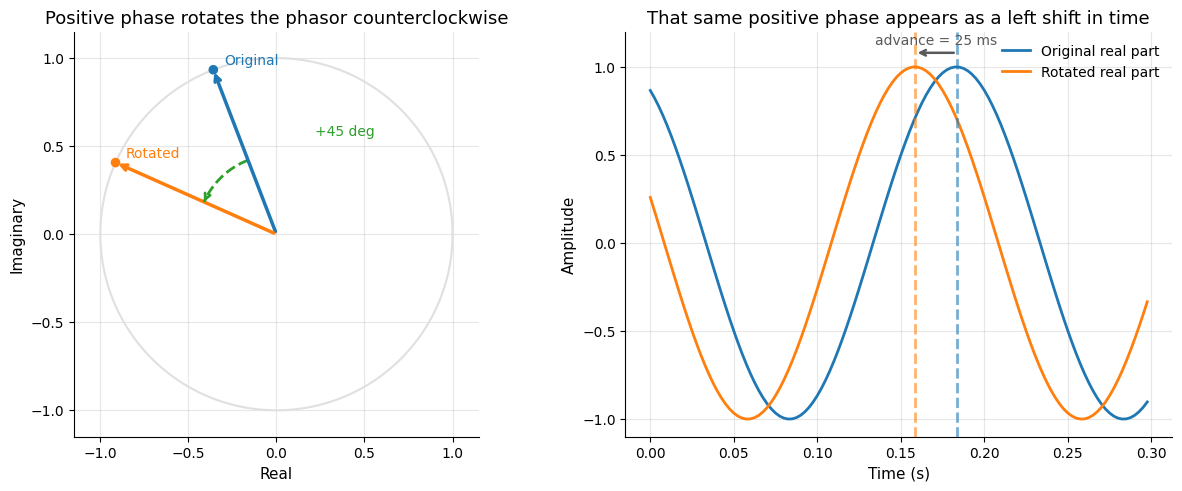

In [ ]:
phi_rot = np.pi / 4.0
z_rot = z * np.exp(1j * phi_rot)
delta_t = phi_rot / (2.0 * np.pi * f_complex)

sample_idx = np.arange(120)
phasor_sample = 18
orig_angle = np.angle(z[phasor_sample])
rot_angle = np.angle(z_rot[phasor_sample])
if rot_angle < orig_angle:
    rot_angle += 2.0 * np.pi
theta_arc = np.linspace(orig_angle, rot_angle, 60)
arc_radius = 0.45
t_peak_orig = (2.0 * np.pi - phase0) / (2.0 * np.pi * f_complex)
t_peak_rot = t_peak_orig - delta_t

fig, axes = make_figure(nrows=1, ncols=2, figsize=(11.8, 4.8))
axes[0].plot(np.cos(theta), np.sin(theta), color="0.88", linewidth=1.5)
axes[0].annotate("", xy=(np.real(z[phasor_sample]), np.imag(z[phasor_sample])), xytext=(0.0, 0.0), arrowprops=dict(arrowstyle="->", color="C0", lw=2.5))
axes[0].annotate("", xy=(np.real(z_rot[phasor_sample]), np.imag(z_rot[phasor_sample])), xytext=(0.0, 0.0), arrowprops=dict(arrowstyle="->", color="C1", lw=2.5))
axes[0].plot(arc_radius * np.cos(theta_arc), arc_radius * np.sin(theta_arc), linestyle="--", linewidth=2.0, color="C2")
axes[0].annotate("", xy=(arc_radius * np.cos(theta_arc[-1]), arc_radius * np.sin(theta_arc[-1])), xytext=(arc_radius * np.cos(theta_arc[-2]), arc_radius * np.sin(theta_arc[-2])), arrowprops=dict(arrowstyle="->", color="C2", lw=2.0))
axes[0].scatter([np.real(z[phasor_sample]), np.real(z_rot[phasor_sample])], [np.imag(z[phasor_sample]), np.imag(z_rot[phasor_sample])], color=["C0", "C1"], s=35, zorder=3)
axes[0].text(np.real(z[phasor_sample]) + 0.06, np.imag(z[phasor_sample]) + 0.03, "Original", color="C0")
axes[0].text(np.real(z_rot[phasor_sample]) + 0.06, np.imag(z_rot[phasor_sample]) + 0.03, "Rotated", color="C1")
axes[0].text(0.22, 0.56, "+45 deg", color="C2")
axes[0].set_title("Positive phase rotates the phasor counterclockwise")
axes[0].set_xlabel("Real")
axes[0].set_ylabel("Imaginary")
axes[0].grid(True, alpha=0.3)
axes[0].set_aspect("equal", adjustable="box")
axes[0].set_xlim(-1.15, 1.15)
axes[0].set_ylim(-1.15, 1.15)

plot_signals(t_complex[sample_idx], [np.real(z[sample_idx]), np.real(z_rot[sample_idx])], ax=axes[1], labels=["Original real part", "Rotated real part"], title="That same positive phase appears as a left shift in time", xlabel="Time (s)", ylabel="Amplitude")
axes[1].axvline(t_peak_orig, color="C0", linestyle="--", alpha=0.6)
axes[1].axvline(t_peak_rot, color="C1", linestyle="--", alpha=0.6)
axes[1].annotate("", xy=(t_peak_rot, 1.08), xytext=(t_peak_orig, 1.08), arrowprops=dict(arrowstyle="->", color="0.35", lw=1.8))
axes[1].text((t_peak_orig + t_peak_rot) / 2.0, 1.11, f"advance = {1e3 * delta_t:.0f} ms", ha="center", va="bottom", color="0.35")
axes[1].set_ylim(-1.1, 1.2)
axes[1].legend(loc="upper right")
plt.show()


## Positive and Negative Frequency

A real cosine can be written as the sum of two complex exponentials:

$$\cos(2\pi f t) = \tfrac{1}{2}e^{j2\pi f t} + \tfrac{1}{2}e^{-j2\pi f t}. $$

The positive-frequency term rotates one way in the complex plane. The negative-frequency term rotates the other way. For real signals, both are present together in a conjugate-symmetric pair.


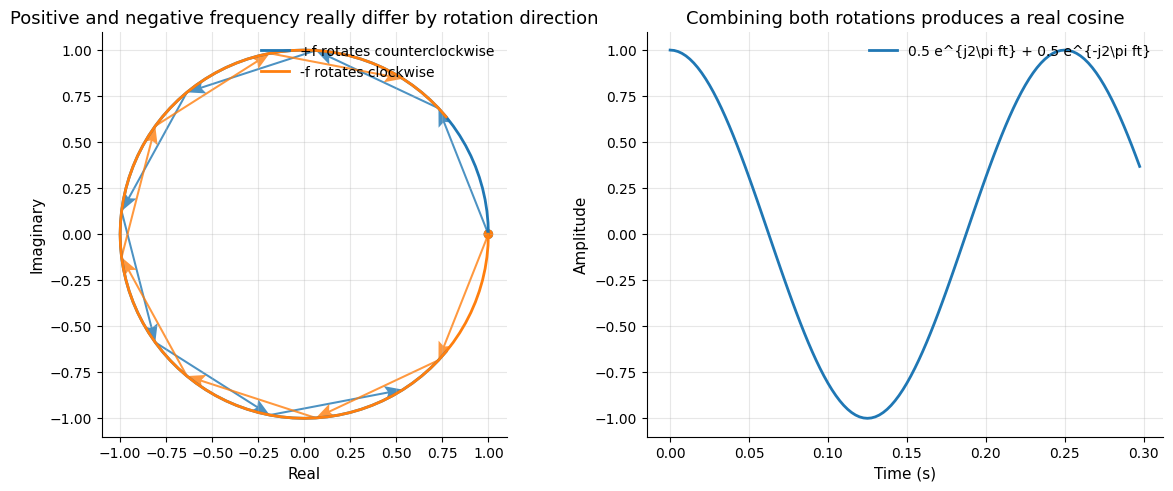

In [7]:
f_pm = 4.0
t_pm, z_pos = complex_exponential(f_pm, fs, 0.75, amplitude=1.0, phase_rad=0.0)
_, z_neg = complex_exponential(-f_pm, fs, 0.75, amplitude=1.0, phase_rad=0.0)
x_cos = 0.5 * z_pos + 0.5 * z_neg

phasor_idx = np.arange(90)
phasor_step = 12

fig, axes = make_figure(nrows=1, ncols=2, figsize=(11.5, 4.8))
axes[0].plot(np.real(z_pos[phasor_idx]), np.imag(z_pos[phasor_idx]), linewidth=2.0, label="+f rotates counterclockwise")
axes[0].plot(np.real(z_neg[phasor_idx]), np.imag(z_neg[phasor_idx]), linewidth=2.0, label="-f rotates clockwise")
axes[0].scatter([np.real(z_pos[0]), np.real(z_neg[0])], [np.imag(z_pos[0]), np.imag(z_neg[0])], color=["C0", "C1"], s=35)
axes[0].quiver(np.real(z_pos[phasor_idx[:-phasor_step:phasor_step]]), np.imag(z_pos[phasor_idx[:-phasor_step:phasor_step]]), np.real(z_pos[phasor_idx[phasor_step::phasor_step]]) - np.real(z_pos[phasor_idx[:-phasor_step:phasor_step]]), np.imag(z_pos[phasor_idx[phasor_step::phasor_step]]) - np.imag(z_pos[phasor_idx[:-phasor_step:phasor_step]]), angles="xy", scale_units="xy", scale=1.0, width=0.005, headwidth=7.0, headlength=9.0, headaxislength=7.5, color="C0", alpha=0.8)
axes[0].quiver(np.real(z_neg[phasor_idx[:-phasor_step:phasor_step]]), np.imag(z_neg[phasor_idx[:-phasor_step:phasor_step]]), np.real(z_neg[phasor_idx[phasor_step::phasor_step]]) - np.real(z_neg[phasor_idx[:-phasor_step:phasor_step]]), np.imag(z_neg[phasor_idx[phasor_step::phasor_step]]) - np.imag(z_neg[phasor_idx[:-phasor_step:phasor_step]]), angles="xy", scale_units="xy", scale=1.0, width=0.005, headwidth=7.0, headlength=9.0, headaxislength=7.5, color="C1", alpha=0.8)
axes[0].set_title("Positive and negative frequency really differ by rotation direction")
axes[0].set_xlabel("Real")
axes[0].set_ylabel("Imaginary")
axes[0].grid(True, alpha=0.3)
axes[0].set_aspect("equal", adjustable="box")
axes[0].legend(loc="upper right")

plot_signals(t_pm[:120], [np.real(x_cos[:120])], ax=axes[1], labels=["0.5 e^{j2\\pi ft} + 0.5 e^{-j2\\pi ft}"], title="Combining both rotations produces a real cosine", xlabel="Time (s)", ylabel="Amplitude")
axes[1].legend(loc="upper right")
plt.show()


Negative frequency is not a separate physical sensor phenomenon. It is part of the mathematical representation that makes real signals and complex modulation behave cleanly. This becomes important once we begin working with spectra, analytic signals, and baseband processing.


## Superposition: More Than One Tone At Once

Real signals are often sums of multiple components. If two tones are close in frequency, their phase relationship evolves slowly and we observe beating.


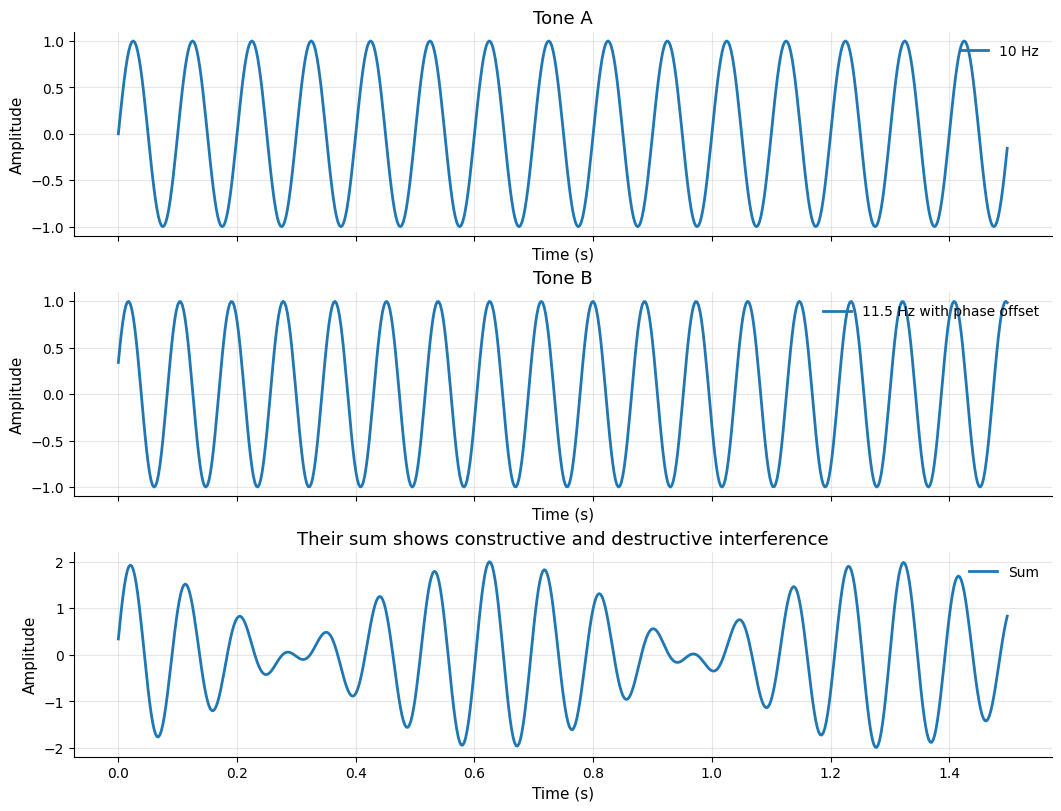

In [8]:
t_mix = time_axis(int(1.5 * fs), fs)
tone_a = np.sin(2.0 * np.pi * 10.0 * t_mix)
tone_b = np.sin(2.0 * np.pi * 11.5 * t_mix + np.deg2rad(20.0))
mixture = tone_a + tone_b

fig, axes = make_figure(nrows=3, ncols=1, figsize=(10.5, 8.0), sharex=True)
plot_signal(t_mix, tone_a, ax=axes[0], title="Tone A", xlabel="Time (s)", ylabel="Amplitude", label="10 Hz")
axes[0].legend(loc="upper right")
plot_signal(t_mix, tone_b, ax=axes[1], title="Tone B", xlabel="Time (s)", ylabel="Amplitude", label="11.5 Hz with phase offset")
axes[1].legend(loc="upper right")
plot_signal(t_mix, mixture, ax=axes[2], title="Their sum shows constructive and destructive interference", xlabel="Time (s)", ylabel="Amplitude", label="Sum")
axes[2].legend(loc="upper right")
plt.show()


This is an early interference example. When components line up in phase, the sum grows. When they oppose one another, the sum shrinks. That same idea later appears across array elements and along synthetic apertures.


## A Simple Delay-and-Phase Bridge to Beamforming Intuition

Imagine two sensors receiving the same narrowband tone, but one sensor sees it slightly later. For that tone, the delay appears mainly as a phase offset. If we align the phase before summing, the signals reinforce one another. If we misalign them badly enough, they can cancel almost completely in the idealized case.


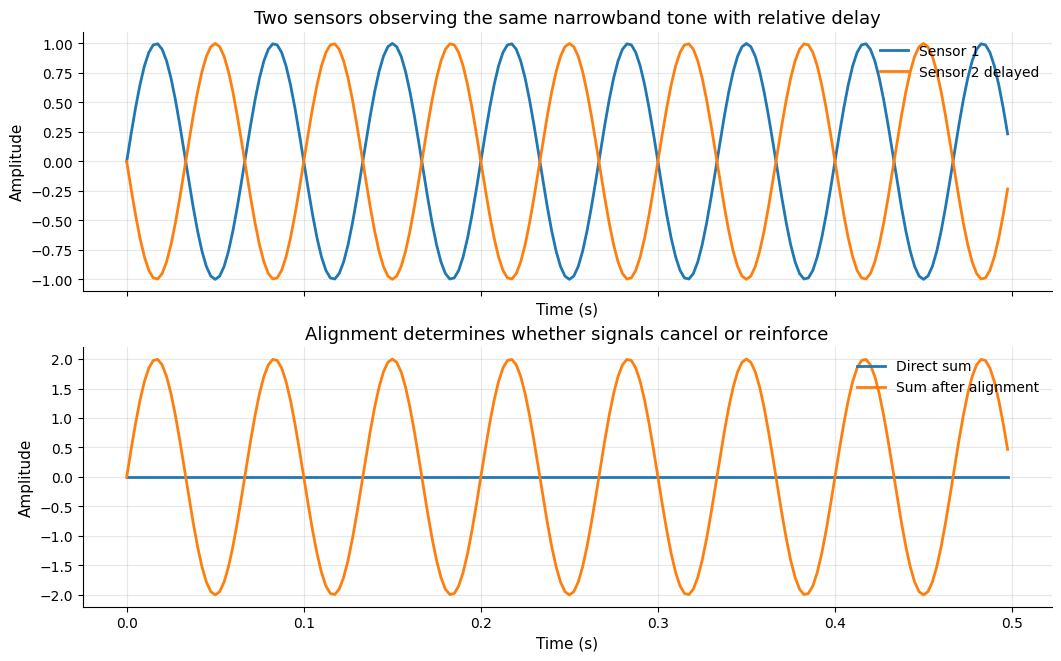

The 33.3 ms inter-sensor delay corresponds to a wrapped phase lag of -180.0 deg at 15.0 Hz.
Peak magnitude before alignment: 0.00; after alignment: 2.00.


In [9]:
f_sensor = 15.0
delay_sensor_s = 1.0 / (2.0 * f_sensor)
t_sensor = time_axis(int(0.5 * fs), fs)
sensor_1 = np.sin(2.0 * np.pi * f_sensor * t_sensor)
sensor_2 = np.sin(2.0 * np.pi * f_sensor * (t_sensor - delay_sensor_s))
sensor_2_aligned = np.sin(2.0 * np.pi * f_sensor * (t_sensor - delay_sensor_s) + 2.0 * np.pi * f_sensor * delay_sensor_s)
phase_corrected_sum = sensor_1 + sensor_2_aligned
uncorrected_sum = sensor_1 + sensor_2
uncorrected_peak = np.max(np.abs(uncorrected_sum))
aligned_peak = np.max(np.abs(phase_corrected_sum))

fig, axes = make_figure(nrows=2, ncols=1, figsize=(10.5, 6.5), sharex=True)
plot_signals(t_sensor, [sensor_1, sensor_2], ax=axes[0], labels=["Sensor 1", "Sensor 2 delayed"], title="Two sensors observing the same narrowband tone with relative delay", xlabel="Time (s)", ylabel="Amplitude")
axes[0].legend(loc="upper right")
plot_signals(t_sensor, [uncorrected_sum, phase_corrected_sum], ax=axes[1], labels=["Direct sum", "Sum after alignment"], title="Alignment determines whether signals cancel or reinforce", xlabel="Time (s)", ylabel="Amplitude")
axes[1].legend(loc="upper right")
plt.show()

sensor_phase_lag_deg = np.rad2deg(((-2.0 * np.pi * f_sensor * delay_sensor_s) + np.pi) % (2.0 * np.pi) - np.pi)
print(f"The {1e3 * delay_sensor_s:.1f} ms inter-sensor delay corresponds to a wrapped phase lag of {sensor_phase_lag_deg:.1f} deg at {f_sensor:.1f} Hz.")
print(f"Peak magnitude before alignment: {uncorrected_peak:.2f}; after alignment: {aligned_peak:.2f}.")


## Tradeoffs and Limitations

Several important limits are hidden inside these clean pictures:

- A single phase offset maps neatly to a delay only for a narrowband signal or for one frequency component at a time.
- Phase is usually wrapped modulo $2\pi$, so a large delay can look identical to a smaller one plus whole cycles.
- In noisy data, phase estimates become unstable when amplitude is weak or coherence is poor.
- Real systems also have carrier drift, clock mismatch, and calibration errors that corrupt relative phase.

These are exactly the reasons later notebooks will care about bandwidth, matched filtering, array calibration, and coherent processing.


## Recap

Sinusoids are the simplest oscillatory building blocks, but they already contain most of the ideas that matter later: timing, alignment, interference, and compact complex representation. The real payoff of this notebook is not the formulas alone. It is the habit of interpreting phase as a relative geometric quantity that controls whether information adds coherently or falls apart.


## Next Questions

- Next we will move from single tones to Fourier-transform intuition, where complex exponentials become the analysis basis.
- Keep watching for the same phase ideas to reappear in spectra, array steering, and SAS phase history.
- A good self-check is to ask whether a visual difference is caused by amplitude, frequency, delay, or only phase alignment.
